# iSIM start guide

Basic usage of the iChem module to calculate the average similarity of a set. 

It includes:
-   Fingerprint generation
-   Calculation of iSIM (average similarity approximation)
-   Calculation of iSIM-sigma (standard deviation of similarities approximation)
-   Calculation of complementary similarity 
-   Identification of medoid
-   Identification of outlier

Author: Kenneth Lopez Perez

In [1]:
import numpy as np

from iChem.iSIM import calculate_comp_sim, calculate_isim, calculate_medoid, calculate_outlier
from iChem.iSIM.sigma import stratified_sigma
from iChem.utils import binary_fps, load_smiles
from iChem.visualization.mol_images import smiles_to_grid_image

### Fingerprint generation

Let's load some smiles from natural products, and then generate some fingerprints.

In [25]:
smiles = load_smiles('../tests/data/mcule_natural_products.smi')

# You can specify different fingerprint types ['ECFP4', 'ECFP6', 'MACCS', 'AP', 'TT', 'MACCS']
# You can also change the number of bits, multiples of 8 are recommended to be able to pack for bblean clustering
fps, _invalid = binary_fps(smiles,
                 fp_type='ECFP6',
                 n_bits=1024,
                 return_invalid=True) # Invalid SMILES will be returned as a separate list

if len(_invalid) > 0:
    print(f'Warning: {len(_invalid)} invalid SMILES were found.')

### Calculation of iSIM

Now let's calculate the average similarity of the natural products set.
Note that we can use different similarity indexes for this, in this example we include JT, RR, and SM.

In [26]:
isim = calculate_isim(fps, n_ary='JT') # We use JT for Jaccard-Tanimoto (aka Tanimoto) similarity
print(f'Average iSIM: {isim:.4f}')

Average iSIM: 0.0995


In [23]:
isim = calculate_isim(fps, n_ary='RR') # We use RR for Russell-Rao similarity
print(f'Average iSIM: {isim:.4f}')

Average iSIM: 0.0115


In [24]:
isim = calculate_isim(fps, n_ary='SM') # We use SM for Sokal-Michener similarity
print(f'Average iSIM: {isim:.4f}')

Average iSIM: 0.8956


### Calculation of iSIM-sigma

Now that we know the average similarity, let's calculate the standard deviation of the similarities. In this way, we will have a better understanding of the distribution of similarities.

In [28]:
isim_sigma = stratified_sigma(fps,
                              n_ary='JT')
print(f'iSIM Sigma: {isim_sigma:.4f}')

iSIM Sigma: 0.0531


In [29]:
isim_sigma = stratified_sigma(fps,
                              n_ary='RR')
print(f'iSIM Sigma: {isim_sigma:.4f}')

iSIM Sigma: 0.0075


In [30]:
isim_sigma = stratified_sigma(fps,
                              n_ary='SM')
print(f'iSIM Sigma: {isim_sigma:.4f}')

iSIM Sigma: 0.0279


### Calculation of complementary similarity
Now we will introduce the concept of complementary similarity. It consist of the similarity when a molecule is left out of a set. After removing it, a high complementary similarity value means that the molecule is an outlier, a low complementary similarity value means that it is a medoid. 

The medoid is the molecule that is the most similar to the rest of the set (lowest complementary similarity).

We will calculate the complementary similarity for each of the molecules in the natural products set. For simplicity, we will carry out only Tanimoto calculations for the rest of the notebook.

In [39]:
comp_sim = calculate_comp_sim(fps, n_ary='JT')
ranking_indices = np.argsort(comp_sim)

Let's use it now to rank the molecules.

Top 5 compounds by complementary similarity:


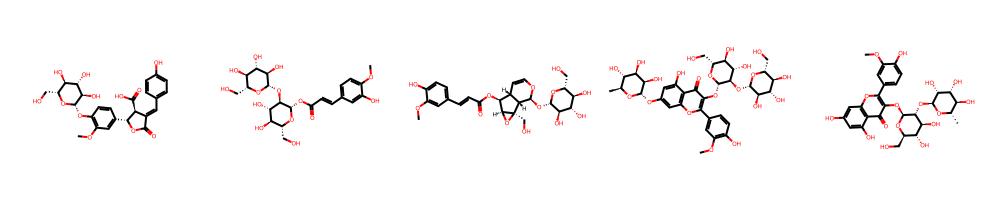

In [43]:
smiles_sorted_by_comp_sim = [smiles[i] for i in ranking_indices]

print('Top 5 compounds by complementary similarity:')
smiles_to_grid_image(smiles_sorted_by_comp_sim[:5], mols_per_row=5, sub_img_size=(200,200))

Bottom 5 compounds by complementary similarity:


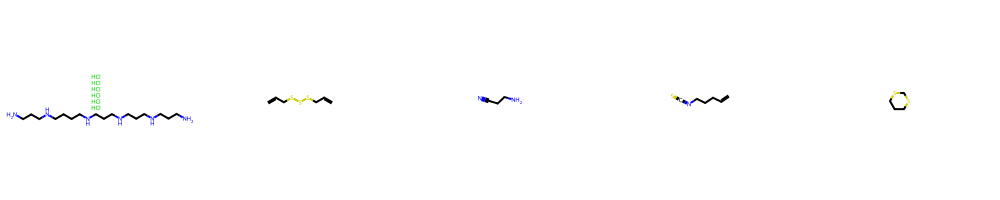

In [44]:
print('Bottom 5 compounds by complementary similarity:')
smiles_to_grid_image(smiles_sorted_by_comp_sim[-5:], mols_per_row=5, sub_img_size=(200,200))

### Identification of the medoid and outlier

We also include functions in case the user wants to get directly the one medoid and the one outlier without having to do the sorting step. 

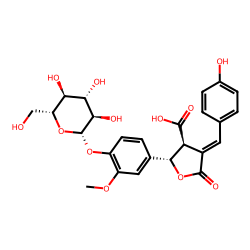

In [47]:
medoid = calculate_medoid(fps, n_ary='JT')
smiles_to_grid_image([smiles[medoid]],
                     mols_per_row=1)

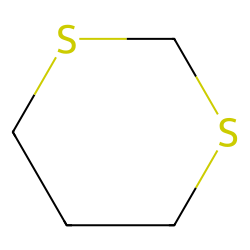

In [48]:
outlier = calculate_outlier(fps, n_ary='JT')
smiles_to_grid_image([smiles[outlier]],
                     mols_per_row=1)